In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data = pd.read_csv('train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_test = data[0:1000].T
Y_test = data_test[0]
X_test = data_test[1:n]
X_test = X_test / 255.0

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.0   

In [4]:
def init_params():
    W1 = np.random.rand(32, 784) - 0.5
    b1 = np.random.rand(32, 1) - 0.5
    W2 = np.random.rand(10, 32) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = X.shape[1]
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

def compute_loss(A2, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    loss = -np.sum(one_hot_Y * np.log(A2 + 1e-8)) / m
    return loss

In [5]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        loss = compute_loss(A2, Y)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            predictions = get_predictions(A2)
            accuracy = get_accuracy(predictions, Y)

            print("Iteration:", i)
            print("Loss:", loss)
            print("Accuracy:", accuracy)
            print("----------------")
    return W1, b1, W2, b2

In [6]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

[5 9 2 ... 3 9 3] [1 8 5 ... 4 3 0]
Iteration: 0
Loss: 4.718882162382357
Accuracy: 0.1111219512195122
----------------
[8 9 6 ... 4 3 7] [1 8 5 ... 4 3 0]
Iteration: 10
Loss: 2.107217608530468
Accuracy: 0.29778048780487804
----------------
[8 6 5 ... 9 3 0] [1 8 5 ... 4 3 0]
Iteration: 20
Loss: 1.5890695845866756
Accuracy: 0.4648536585365854
----------------
[1 6 5 ... 4 3 0] [1 8 5 ... 4 3 0]
Iteration: 30
Loss: 1.2999848628279382
Accuracy: 0.5675121951219512
----------------
[1 6 5 ... 4 3 0] [1 8 5 ... 4 3 0]
Iteration: 40
Loss: 1.1103242121924926
Accuracy: 0.6392926829268293
----------------
[1 6 5 ... 4 3 0] [1 8 5 ... 4 3 0]
Iteration: 50
Loss: 0.9820145709637992
Accuracy: 0.6839512195121952
----------------
[1 6 5 ... 4 3 0] [1 8 5 ... 4 3 0]
Iteration: 60
Loss: 0.8916283087693847
Accuracy: 0.7137073170731707
----------------
[1 6 5 ... 4 3 0] [1 8 5 ... 4 3 0]
Iteration: 70
Loss: 0.8247178409154995
Accuracy: 0.7357073170731707
----------------
[1 6 5 ... 4 3 0] [1 8 5 ... 4 3 0

In [7]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [1]
Label:  1


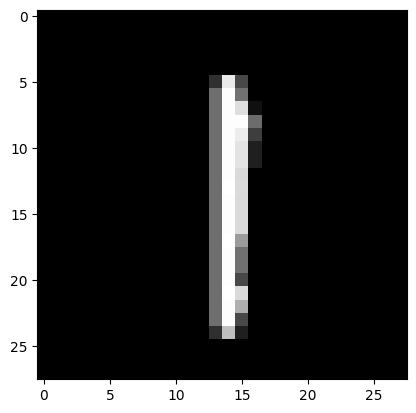

Prediction:  [8]
Label:  8


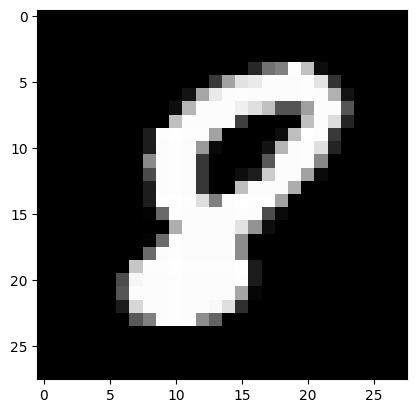

Prediction:  [5]
Label:  5


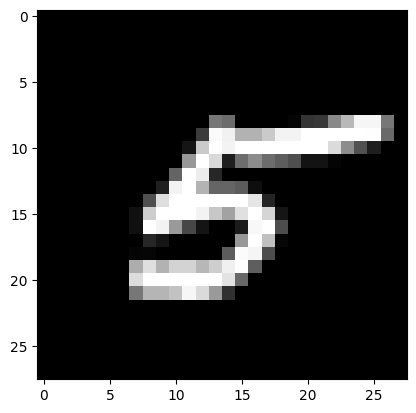

Prediction:  [5]
Label:  3


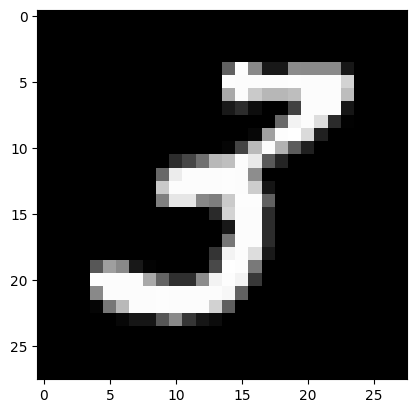

In [8]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [9]:
test_predictions = make_predictions(X_test, W1, b1, W2, b2)
get_accuracy(test_predictions, Y_test)

[9 3 1 2 0 9 9 4 9 9 1 7 3 9 8 9 9 3 1 2 6 0 5 8 9 5 2 8 2 8 9 9 3 3 6 9 5
 7 0 1 7 9 0 8 9 1 6 7 2 9 4 3 2 4 5 5 6 3 9 3 6 8 6 7 9 6 1 2 8 2 9 4 9 6
 5 2 9 0 7 9 7 9 0 6 7 3 4 9 0 6 4 6 3 3 1 7 7 9 2 6 3 0 6 0 3 6 9 4 8 1 7
 2 3 4 6 7 2 9 3 8 5 0 8 8 2 8 0 8 9 8 1 6 0 7 8 3 2 2 4 8 1 9 2 2 6 3 3 7
 0 9 1 2 4 0 0 5 8 3 5 3 9 3 2 4 0 8 8 2 4 3 0 8 7 0 9 2 2 0 3 6 0 8 1 6 8
 7 9 6 8 5 5 5 2 3 8 2 1 1 1 3 4 6 1 0 2 8 8 0 8 7 6 9 6 6 7 0 3 7 1 0 7 5
 3 0 7 3 6 5 5 4 8 8 4 8 9 4 2 0 2 0 2 7 4 5 4 7 6 1 5 4 0 8 2 9 4 5 5 0 1
 1 9 0 4 4 6 6 5 4 9 4 0 5 4 9 7 4 3 8 9 6 0 4 1 2 9 1 8 1 6 2 8 5 9 8 7 0
 9 9 4 1 6 7 2 5 2 6 7 5 2 3 4 2 8 4 1 5 1 0 5 0 4 6 3 4 7 7 7 9 0 2 6 6 1
 4 3 6 3 8 4 6 6 1 2 8 2 3 2 1 9 2 1 7 0 8 3 2 9 6 1 4 0 0 1 1 9 4 2 6 1 9
 5 0 4 2 0 5 1 5 9 9 4 5 0 1 3 2 7 7 0 0 9 9 6 8 7 4 2 6 6 3 4 9 3 6 1 0 3
 5 1 2 9 3 2 0 1 3 1 9 4 2 5 1 6 9 4 8 3 3 2 3 6 3 2 3 2 4 6 9 7 8 5 8 5 9
 8 2 4 7 1 8 8 6 5 7 2 8 7 9 3 4 3 0 8 7 5 2 6 7 6 8 6 8 3 8 7 8 3 4 1 9 9
 4 8 1 8 8 3 9 9 4 8 5 4 

np.float64(0.878)